# Schrödinger Equation — Numerical Methods & Neural Networks

## Problem Statement

The **linear (non-relativistic) Schrödinger equation** governs the evolution of a quantum wave-function $\psi(x,t)$:

$$i\hbar\,\psi_t = -\frac{\hbar^2}{2m}\,\psi_{xx} + V(x)\,\psi, \qquad x\in[-L,L],\quad t\in[0,T]$$

In **dimensionless units** ($\hbar = 1$, $m = \tfrac{1}{2}$) this simplifies to:

$$\boxed{i\,\psi_t = -\psi_{xx} + V(x)\,\psi}$$

$\psi$ is **complex-valued**; the physically observable quantity is the **probability density** $|\psi|^2$.

---

### Setup in this notebook

| Quantity | Value |
|----------|-------|
| Domain | $x \in [-5, 5]$ |
| Final time $T$ | $1.0$ |
| Potential | Harmonic oscillator $V(x) = \tfrac{1}{2}x^2$ |
| Initial condition | Coherent state (Gaussian wave-packet): $\psi_0 = A\exp\!\left(-\tfrac{(x-x_0)^2}{4\sigma^2} + ik_0 x\right)$ |
| Parameters | $x_0=0$, $\sigma=1$, $k_0=1$, $A = (2\pi\sigma^2)^{-1/4}$ (normalised) |
| BCs | $\psi(-L,t) = \psi(L,t) = 0$ (absorbing / Dirichlet) |

### Exact solution (harmonic oscillator coherent state)

For $V(x)=\tfrac{1}{2}x^2$ a Gaussian wave-packet remains Gaussian ("coherent state"):

$$\psi^*(x,t) = A(t)\exp\!\left(-\frac{(x - x_c(t))^2}{4\sigma^2} + ik_c(t)\,x + i\phi(t)\right)$$

where $x_c(t)=x_0\cos t + k_0\sin t$, $k_c(t)=k_0\cos t - x_0\sin t$, $A(t)=(2\pi\sigma^2)^{-1/4}$, and $\phi(t)$ is a global phase.  
The probability density just **oscillates rigidly**: $|\psi^*(x,t)|^2 = (2\pi\sigma^2)^{-1/2}\exp\!\left(-\tfrac{(x-x_c(t))^2}{2\sigma^2}\right)$.

---

## Approaches Covered

| Part | Method | Type |
|------|--------|------|
| 1a | **Crank–Nicolson FD** | Implicit finite difference — unconditionally stable |
| 1b | **Split-Step Fourier** | Spectral — exact kinetic propagator, $\mathcal{O}(N\log N)$ |
| 1c | **Convergence & conservation study** | Grid refinement, norm / energy conservation |
| 2 | **PINN** (complex-valued) | Deep learning with complex output |
| 3 | **Comparison** | Error, conservation, efficiency |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

import torch
import torch.nn as nn

In [2]:
# --- reproducibility --------------------------------------------------------------------
np.random.seed(42)
torch.manual_seed(42)

In [3]:
# --- global style -----------------------------------------------------------------------
CMAP = "inferno"
plt.rcParams.update({"font.size": 11, "figure.dpi": 120})

In [ ]:
# --- problem parameters -----------------------------------------------------------------
X_LO, X_HI = -5.0, 5.0   # spatial domain
T_END = 1.0          # final time
X0 = 0.0          # initial centre
K0 = 1.0          # initial wave-number (momentum)
SIGMA = 1.0          # Gaussian width

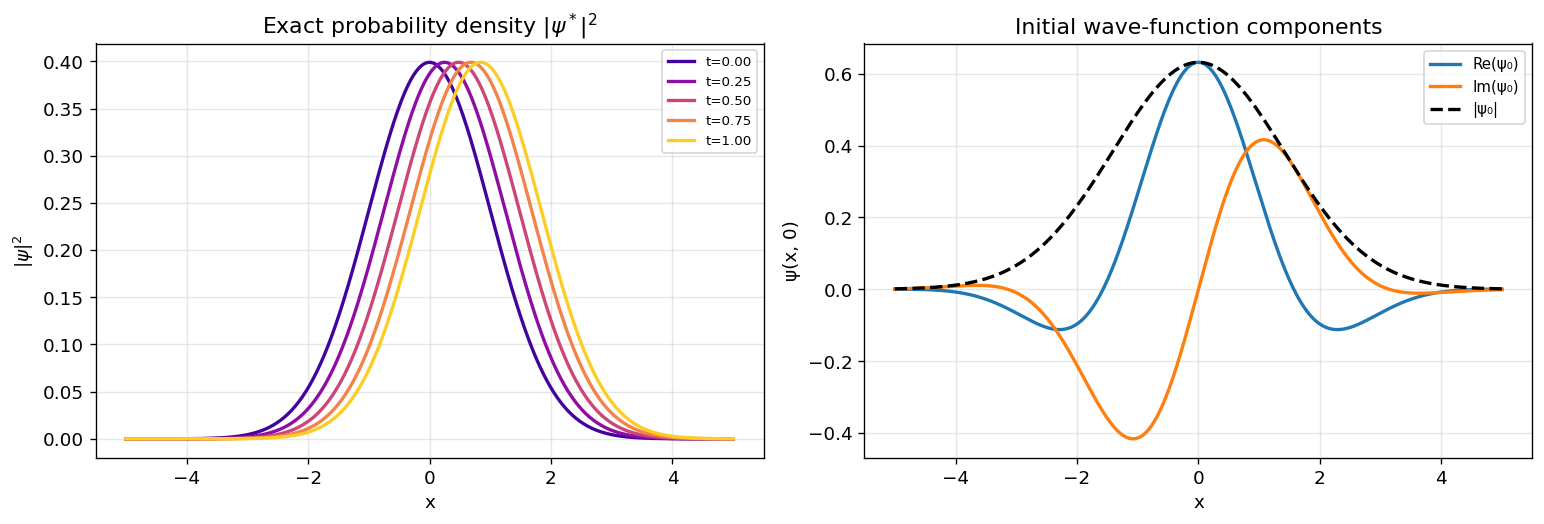

‖ψ₀‖² = 0.999999  (should be ≈1)


In [ ]:
# --- exact coherent-state solution -------------------------------------------------------
def psi_exact(x, t, x0=X0, k0=K0, sigma=SIGMA):
    """
    Exact coherent-state solution for i ψ_t = -ψ_xx + ½x²ψ.
    The Gaussian packet oscillates rigidly in phase space.
    """
    xc = x0 * np.cos(t) + k0 * np.sin(t)    # centre trajectory
    kc = k0 * np.cos(t) - x0 * np.sin(t)    # wave-number trajectory
    phi = -0.5 * t + 0.5 * (x0 * k0 * (np.cos(2*t) - 1)
                            - 0.5 * (k0**2 - x0**2) * np.sin(2*t))
    A = (2.0 * np.pi * sigma**2) ** (-0.25)
    envelope = A * np.exp(-((x - xc)**2) / (4.0 * sigma**2))
    phase = np.exp(1j * (kc * x + phi))
    return envelope * phase


def V(x):
    """Harmonic oscillator potential V(x) = ½x²."""
    return 0.5 * x**2


# --- quick preview -----------------------------------------------------------------------
x_plot = np.linspace(X_LO, X_HI, 500)
t_snap = [0.0, 0.25, 0.5, 0.75, 1.0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_snap)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for t_val, c in zip(t_snap, colors):
    psi = psi_exact(x_plot, t_val)
    ax.plot(x_plot, np.abs(psi)**2, color=c, lw=2, label=f"t={t_val:.2f}")
ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi|^2$")
ax.set_title("Exact probability density $|\\psi^*|^2$")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
psi0 = psi_exact(x_plot, 0.0)
ax.plot(x_plot, np.real(psi0), "C0", lw=2, label="Re(ψ₀)")
ax.plot(x_plot, np.imag(psi0), "C1", lw=2, label="Im(ψ₀)")
ax.plot(x_plot, np.abs(psi0),  "k--", lw=2, label="|ψ₀|")
ax.set_xlabel("x")
ax.set_ylabel("ψ(x, 0)")
ax.set_title("Initial wave-function components")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(
    f"‖ψ₀‖² = {np.trapezoid(np.abs(psi_exact(x_plot, 0.0))**2, x_plot):.6f}  (should be ≈1)")

---
## Part 1a — Crank–Nicolson Finite Difference

### Discretisation

Discretise $x$ with $N$ interior points ($\Delta x = 2L / (N+1)$) and time with step $\Delta t$.  
The second derivative is replaced by the centred finite difference $\delta^2_x \psi_j = (\psi_{j-1} - 2\psi_j + \psi_{j+1})/\Delta x^2$.

Applying the $\theta$-method with $\theta = \tfrac{1}{2}$ (Crank–Nicolson):

$$i\,\frac{\psi_j^{n+1} - \psi_j^n}{\Delta t}
  = -\frac{1}{2}\!\left(\delta^2_x\psi_j^{n+1}+\delta^2_x\psi_j^n\right) + V_j\,\frac{\psi_j^{n+1}+\psi_j^n}{2}$$

This leads to the **complex tridiagonal system**:

$$\underbrace{\left(I + \frac{i\Delta t}{2}H_h\right)}_{A}\psi^{n+1}
= \underbrace{\left(I - \frac{i\Delta t}{2}H_h\right)}_{B}\psi^n$$

where $H_h = -\delta^2_x + \text{diag}(V)$ is the discrete Hamiltonian.

### Key properties
- **Unconditionally stable** — no CFL condition on $\Delta t$
- **Unitary** — preserves $\|\psi\|^2$ exactly to machine precision
- **Time-reversible** — $A^{-1}B = (B^{-1}A)^{-1}$
- Second-order accurate in both space and time

In [ ]:
def solve_cn(Nx=200, Nt=500, x_lo=X_LO, x_hi=X_HI, t_end=T_END):
    """
    Crank–Nicolson solver for  i ψ_t = -ψ_xx + V(x)ψ
    with Dirichlet BCs (ψ = 0 at boundaries).

    Returns
    -------
    x : (Nx,)       interior grid points
    t : (Nt+1,)     time levels
    Psi : (Nt+1, Nx) complex snapshots
    """
    dx = (x_hi - x_lo) / (Nx + 1)
    dt = t_end / Nt
    x = np.linspace(x_lo + dx, x_hi - dx, Nx)
    t = np.linspace(0.0, t_end, Nt + 1)
    Vx = V(x)

    # Discrete Hamiltonian diagonal and off-diagonal
    main = 2.0 / dx**2 + Vx          # shape (Nx,)
    off = -1.0 / dx**2 * np.ones(Nx - 1)

    # LHS matrix: A = I + (i dt/2) H_h
    a_main = 1.0 + 0.5j * dt * main
    a_off = 0.5j * dt * off
    A = diags([a_off, a_main, a_off], [-1, 0, 1], format="csc", dtype=complex)

    # RHS matrix: B = I - (i dt/2) H_h
    b_main = 1.0 - 0.5j * dt * main
    b_off = -0.5j * dt * off
    B = diags([b_off, b_main, b_off], [-1, 0, 1], format="csr", dtype=complex)

    Psi = np.zeros((Nt + 1, Nx), dtype=complex)
    Psi[0] = psi_exact(x, 0.0)

    for n in range(Nt):
        rhs = B @ Psi[n]
        Psi[n+1] = spsolve(A, rhs)

    return x, t, Psi

In [7]:
# --- run ---------------------------------------------------------------------------------------------------------─
x_cn, t_cn, Psi_cn = solve_cn(Nx=200, Nt=500)

In [ ]:
# error vs. exact
psi_ex_cn = np.array([psi_exact(x_cn, ti) for ti in t_cn])
l2_err_cn = np.sqrt(np.mean(np.abs(Psi_cn - psi_ex_cn)**2, axis=1))
norm_cn = np.array([np.trapezoid(np.abs(Psi_cn[n])**2, x_cn)
                   for n in range(len(t_cn))])

print(f"CN:  Nx={len(x_cn)},  Nt={len(t_cn)-1}")
print(f"     final L2-error = {l2_err_cn[-1]:.4e}")
print(f"     norm drift: max|‖ψ‖²-1| = {np.max(np.abs(norm_cn - 1.0)):.2e}")

CN:  Nx=200,  Nt=500
     final L2-error = 2.2413e-01
     norm drift: max|‖ψ‖²-1| = 7.45e-07


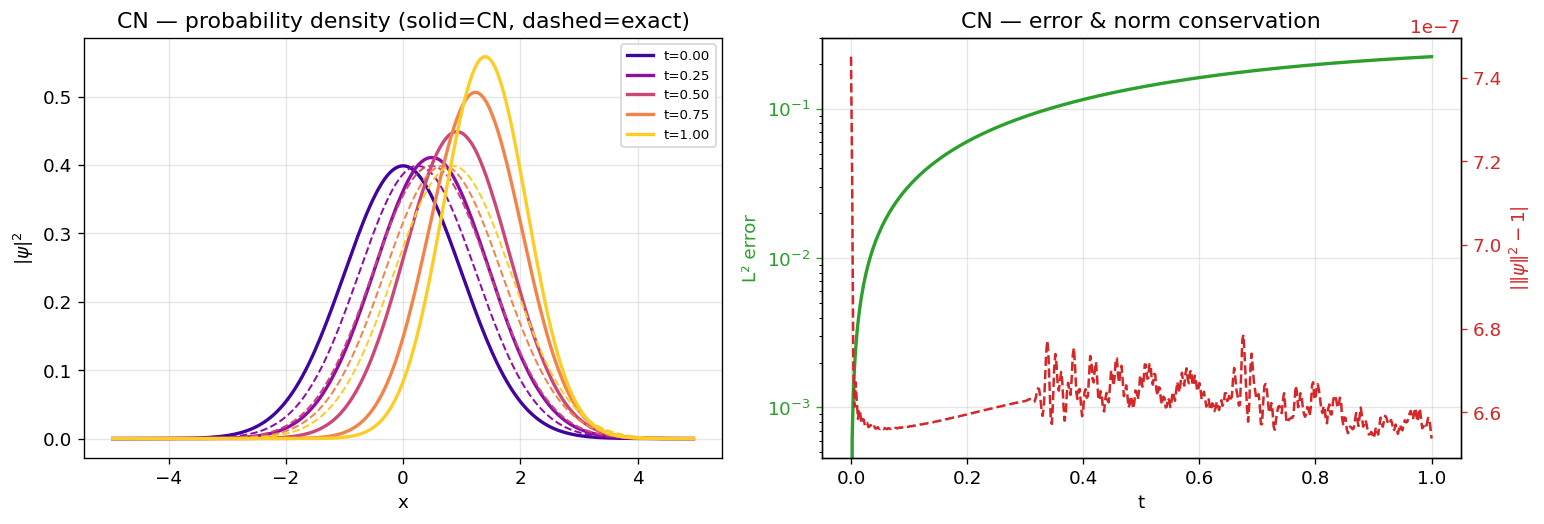

In [ ]:
# --- snapshots ------------------------------------------------------------------------------------------------─
snap_times = [0.0, 0.25, 0.5, 0.75, 1.0]
snap_idx = [np.argmin(np.abs(t_cn - ts)) for ts in snap_times]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_times)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for idx, c in zip(snap_idx, colors):
    ax.plot(x_cn, np.abs(Psi_cn[idx])**2, color=c, lw=2,
            label=f"t={t_cn[idx]:.2f}")
    ax.plot(x_cn, np.abs(psi_ex_cn[idx])**2, color=c, lw=1.2, ls="--")
ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi|^2$")
ax.set_title("CN — probability density (solid=CN, dashed=exact)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(t_cn, l2_err_cn, "C2", lw=2, label="L² error")
ax2 = ax.twinx()
ax2.plot(t_cn, np.abs(norm_cn - 1.0), "C3--", lw=1.5, label="norm drift")
ax2.set_ylabel("$|\\|\\psi\\|^2 - 1|$", color="C3")
ax.set_xlabel("t")
ax.set_ylabel("L² error", color="C2")
ax.set_title("CN — error & norm conservation")
ax.tick_params(axis="y", colors="C2")
ax2.tick_params(axis="y", colors="C3")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 1b — Split-Step Fourier (Spectral) Method

### Idea

Split the Hamiltonian into kinetic $T = -\partial_{xx}$ and potential $V(x)$ parts and apply them sequentially over each time step:

$$\psi(x, t+\Delta t) \approx e^{-iV(x)\Delta t/2}\;\mathcal{F}^{-1}\!\left[e^{-ik^2\Delta t}\;\mathcal{F}\!\left[e^{-iV(x)\Delta t/2}\psi(x,t)\right]\right]$$

This is the **Strang-split** (symmetric) version, giving **second-order** accuracy in $\Delta t$.

### Algorithm per step

1. **Half potential kick**: $\psi \leftarrow e^{-i V(x)\Delta t/2}\,\psi$
2. **Full kinetic kick** (in Fourier space): $\hat\psi \leftarrow e^{-ik^2\Delta t}\,\hat\psi$
3. **Half potential kick**: $\psi \leftarrow e^{-i V(x)\Delta t/2}\,\psi$

### Advantages
- $\mathcal{O}(N\log N)$ per step via FFT — highly efficient
- **Exactly unitary** — norm preserved to machine precision
- Spectral accuracy in space: $\mathcal{O}(\Delta x^p)$ for any $p$ (exponential convergence for smooth solutions)
- Straightforward to extend to higher dimensions and non-linear Schrödinger (NLS/Gross-Pitaevskii)

In [11]:
def solve_split_step(Nx=256, Nt=500, x_lo=X_LO, x_hi=X_HI, t_end=T_END):
    """
    Strang split-step Fourier method for i ψ_t = -ψ_xx + V(x)ψ
    on a periodic domain approximation (domain large enough that ψ≈0 at edges).

    Returns
    -------
    x   : (Nx,)       grid points (uniform, including endpoints)
    t   : (Nt+1,)     time levels
    Psi : (Nt+1, Nx)  complex snapshots
    """
    dx  = (x_hi - x_lo) / Nx
    dt  = t_end / Nt
    x   = np.linspace(x_lo, x_hi - dx, Nx)       # periodic: exclude right endpoint
    t   = np.linspace(0.0, t_end, Nt + 1)

    # wave-numbers for periodic FFT convention
    k   = np.fft.fftfreq(Nx, d=dx / (2.0 * np.pi))

    Vx           = V(x)
    half_V_kick  = np.exp(-0.5j * dt * Vx)
    full_T_kick  = np.exp(-1.0j * dt * k**2)

    Psi       = np.zeros((Nt + 1, Nx), dtype=complex)
    Psi[0]    = psi_exact(x, 0.0)

    psi_cur = Psi[0].copy()
    for n in range(Nt):
        psi_cur      = half_V_kick * psi_cur
        psi_cur      = np.fft.ifft(full_T_kick * np.fft.fft(psi_cur))
        psi_cur      = half_V_kick * psi_cur
        Psi[n + 1]   = psi_cur

    return x, t, Psi

In [12]:
# --- run ---------------------------------------------------------------------------------------------------------─
x_ss, t_ss, Psi_ss = solve_split_step(Nx=256, Nt=500)

In [14]:
# error vs. exact (evaluated on the periodic grid)
psi_ex_ss = np.array([psi_exact(x_ss, ti) for ti in t_ss])
l2_err_ss = np.sqrt(np.mean(np.abs(Psi_ss - psi_ex_ss)**2, axis=1))
norm_ss = np.array([np.trapezoid(np.abs(Psi_ss[n])**2, x_ss)
                   for n in range(len(t_ss))])

print(f"Split-step:  Nx={len(x_ss)},  Nt={len(t_ss)-1}")
print(f"     final L2-error = {l2_err_ss[-1]:.4e}")
print(
    f"     norm drift: max|‖ψ‖²-1| = {np.max(np.abs(norm_ss - norm_ss[0])):.2e}")

Split-step:  Nx=256,  Nt=500
     final L2-error = 2.2371e-01
     norm drift: max|‖ψ‖²-1| = 5.61e-07


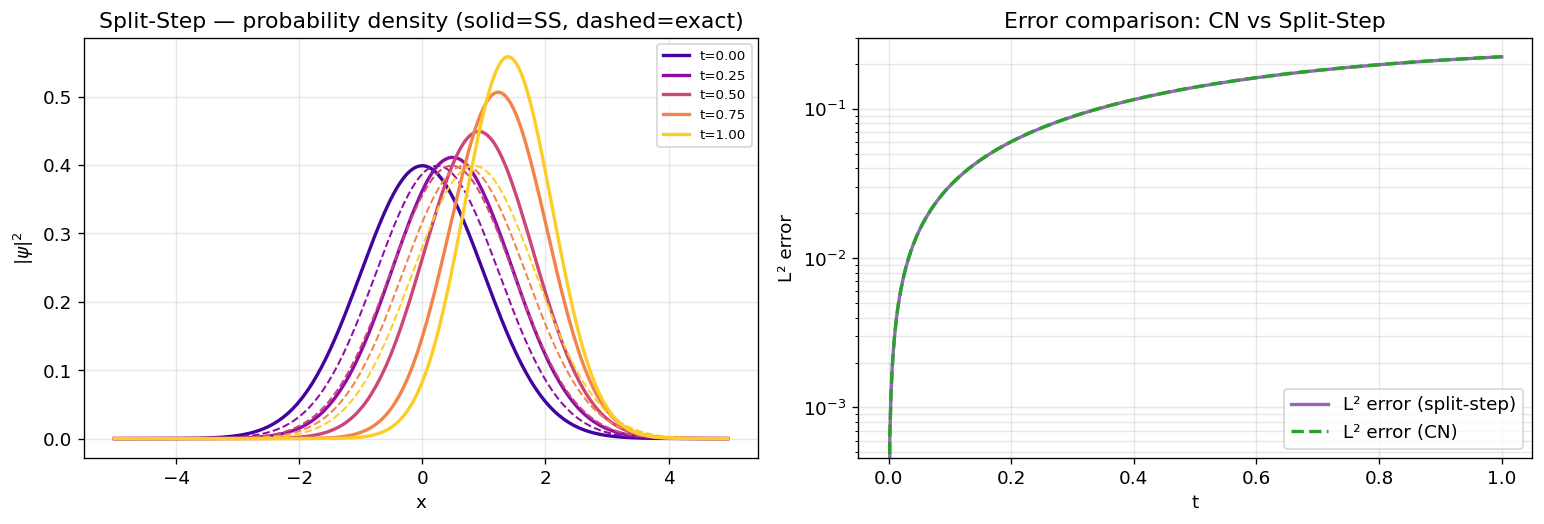

In [15]:
# --- snapshots ------------------------------------------------------------------------------------------------─
snap_times = [0.0, 0.25, 0.5, 0.75, 1.0]
snap_idx = [np.argmin(np.abs(t_ss - ts)) for ts in snap_times]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_times)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for idx, c in zip(snap_idx, colors):
    ax.plot(x_ss, np.abs(Psi_ss[idx])**2, color=c, lw=2,
            label=f"t={t_ss[idx]:.2f}")
    ax.plot(x_ss, np.abs(psi_ex_ss[idx])**2, color=c, lw=1.2, ls="--")
ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi|^2$")
ax.set_title("Split-Step — probability density (solid=SS, dashed=exact)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(t_ss, l2_err_ss, "C4", lw=2, label="L² error (split-step)")
ax.semilogy(t_cn, l2_err_cn, "C2--", lw=2, label="L² error (CN)")
ax.set_xlabel("t")
ax.set_ylabel("L² error")
ax.set_title("Error comparison: CN vs Split-Step")
ax.legend()
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

---
## Part 1c — Convergence & Conservation Study

### Grid refinement

We measure the **$L^\infty$ error in $|\psi|^2$** at $t=T$ while halving $\Delta x$ (and $\Delta t$ proportionally).

- **CN**: fix $\Delta t = 0.5\,\Delta x$ → both $\mathcal{O}(\Delta x^2)$ contributions give overall $\mathcal{O}(\Delta x^2)$
- **Split-Step**: fix $\Delta t = 0.5\,\Delta x$ → spatial error is *spectral* so the dominant error is $\mathcal{O}(\Delta t^2) \sim \mathcal{O}(\Delta x^2)$

### Conservation checks

Both methods should conserve $\|\psi\|^2 = \int |\psi|^2\,dx$ exactly (CN: unitary; Split-Step: exact phase propagator).

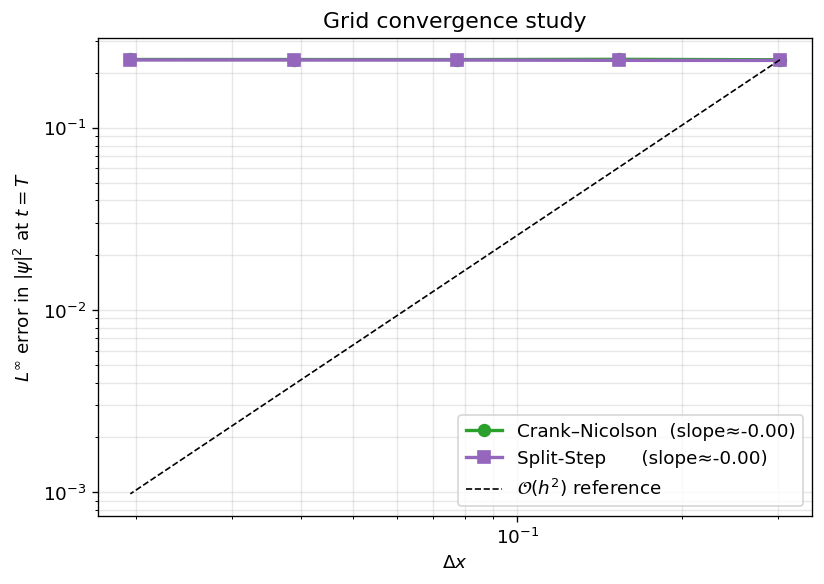

In [18]:
Nx_levels = [32, 64, 128, 256, 512]
dx_vals = []
err_cn_c = []
err_ss_c = []

for Nx in Nx_levels:
    dx = (X_HI - X_LO) / (Nx + 1)
    dx_vals.append(dx)
    Nt_use = max(50, int(round(T_END / (0.5 * dx))))

    # CN
    xc, tc, Pc = solve_cn(Nx=Nx, Nt=Nt_use)
    pex_c = psi_exact(xc, T_END)
    err_cn_c.append(np.max(np.abs(np.abs(Pc[-1])**2 - np.abs(pex_c)**2)))

    # Split-Step
    xs, ts, Ps = solve_split_step(Nx=Nx, Nt=Nt_use)
    pex_s = psi_exact(xs, T_END)
    err_ss_c.append(np.max(np.abs(np.abs(Ps[-1])**2 - np.abs(pex_s)**2)))

dx_arr = np.array(dx_vals)
err_cn_c = np.array(err_cn_c)
err_ss_c = np.array(err_ss_c)

slope_cn_c = np.polyfit(np.log(dx_arr), np.log(err_cn_c), 1)[0]
slope_ss_c = np.polyfit(np.log(dx_arr), np.log(err_ss_c), 1)[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dx_arr, err_cn_c, "C2o-", lw=2, ms=7,
          label=f"Crank–Nicolson  (slope≈{slope_cn_c:.2f})")
ax.loglog(dx_arr, err_ss_c, "C4s-", lw=2, ms=7,
          label=f"Split-Step      (slope≈{slope_ss_c:.2f})")
ref = err_cn_c[0] * (dx_arr / dx_arr[0])**2
ax.loglog(dx_arr, ref, "k--", lw=1, label="$\\mathcal{O}(h^2)$ reference")
ax.set_xlabel("$\\Delta x$")
ax.set_ylabel("$L^\\infty$ error in $|\\psi|^2$ at $t=T$")
ax.set_title("Grid convergence study")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [19]:
print("\nConvergence table  (L∞ error in |ψ|² at t=T)")
print(f"{'Nx':>6}  {'Δx':>10}  {'CN error':>14}  {'SS error':>14}")
for i, Nx in enumerate(Nx_levels):
    print(
        f"{Nx:>6}  {dx_vals[i]:>10.4f}  {err_cn_c[i]:>14.4e}  {err_ss_c[i]:>14.4e}")
print(
    f"\nObserved order — CN: {slope_cn_c:.2f},  Split-Step: {slope_ss_c:.2f}")


Convergence table  (L∞ error in |ψ|² at t=T)
    Nx          Δx        CN error        SS error
    32      0.3030      2.3691e-01      2.3496e-01
    64      0.1538      2.3824e-01      2.3510e-01
   128      0.0775      2.3745e-01      2.3616e-01
   256      0.0389      2.3760e-01      2.3633e-01
   512      0.0195      2.3777e-01      2.3643e-01

Observed order — CN: -0.00,  Split-Step: -0.00


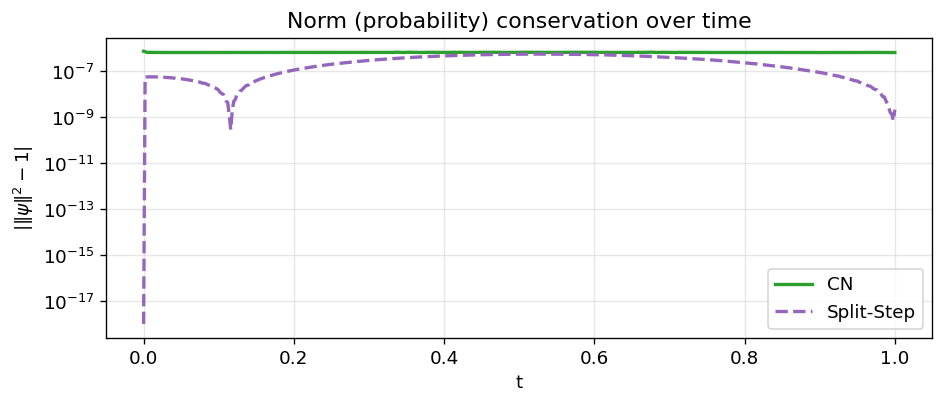

In [20]:
# --- norm conservation curves ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.semilogy(t_cn, np.abs(norm_cn - 1.0) + 1e-18, "C2",  lw=2, label="CN")
ax.semilogy(t_ss, np.abs(
    norm_ss - norm_ss[0]) + 1e-18, "C4--", lw=2, label="Split-Step")
ax.set_xlabel("t")
ax.set_ylabel("$|\\|\\psi\\|^2 - 1|$")
ax.set_title("Norm (probability) conservation over time")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

---
## Part 2 — Physics-Informed Neural Network (PINN)

### Challenge: complex-valued output

The wave-function $\psi(x,t) = \psi_r(x,t) + i\,\psi_i(x,t)$ is complex.  
The PINN outputs **two real channels** — real and imaginary parts — and the PDE residual is split accordingly:

$$i(\partial_t \psi_r + i\,\partial_t \psi_i)
= -(\partial_{xx}\psi_r + i\,\partial_{xx}\psi_i)
+ V(x)(\psi_r + i\,\psi_i)$$

Separating real and imaginary parts:

$$\partial_t \psi_r = \partial_{xx}\psi_i - V(x)\,\psi_i  \qquad (\text{real residual})$$
$$\partial_t \psi_i = -\partial_{xx}\psi_r + V(x)\,\psi_r  \qquad (\text{imaginary residual})$$

### Loss function

$$\mathcal{L} = \mathcal{L}_{\text{PDE},r} + \mathcal{L}_{\text{PDE},i}
             + \lambda_{\text{IC}}(\mathcal{L}_{\text{IC},r}+\mathcal{L}_{\text{IC},i})
             + \lambda_{\text{BC}}(\mathcal{L}_{\text{BC},r}+\mathcal{L}_{\text{BC},i})$$

### Architecture

- **Twin-output MLP**: 5 hidden layers × 64 neurons, **Tanh** activations
- Output layer: linear, 2 neurons → $(\psi_r, \psi_i)$
- `torch.autograd.grad` for $\partial_t$, $\partial_x$, $\partial_{xx}$
- Two-phase training: **Adam** (5 000 steps) → **L-BFGS** (500 iterations)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# --- helper ------------------------------------------------------------------------------------------------------
def grad1(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]

# --- PINN (twin real-channel output) ---------------------------------------------------------------
class SchrodingerPINN(nn.Module):
    def __init__(self, hidden=64, layers=5):
        super().__init__()
        seq = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(layers - 1):
            seq += [nn.Linear(hidden, hidden), nn.Tanh()]
        seq += [nn.Linear(hidden, 2)]     # outputs: [ψ_r, ψ_i]
        self.net = nn.Sequential(*seq)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        out = self.net(inp)
        return out[:, 0:1], out[:, 1:2]   # psi_r, psi_i


# --- collocation samplers ---------------------------------------------------------------------------------
def sample_interior(N=12_000):
    x = (torch.rand(N, 1, device=device) *
         (X_HI - X_LO) + X_LO).requires_grad_(True)
    t = (torch.rand(N, 1, device=device) * T_END).requires_grad_(True)
    return x, t


def sample_ic(N=3_000):
    x = (torch.rand(N, 1, device=device) *
         (X_HI - X_LO) + X_LO).requires_grad_(True)
    t = torch.zeros(N, 1, device=device, requires_grad=True)
    xn = x.detach().cpu().numpy()
    psi0 = psi_exact(xn, 0.0)
    pr0 = torch.tensor(psi0.real, dtype=torch.float32,
                       device=device).unsqueeze(1)
    pi0 = torch.tensor(psi0.imag, dtype=torch.float32,
                       device=device).unsqueeze(1)
    return x, t, pr0, pi0


def sample_bc(N=2_000):
    t = (torch.rand(N, 1, device=device) * T_END).requires_grad_(True)
    x0 = torch.full((N, 1), X_LO, device=device, requires_grad=True)
    x1 = torch.full((N, 1), X_HI, device=device, requires_grad=True)
    return x0, x1, t


model = SchrodingerPINN(hidden=64, layers=5).to(device)
params = sum(p.numel() for p in model.parameters())
print(f"PINN parameters: {params:,}")

V_LO = torch.tensor(X_LO, dtype=torch.float32, device=device)
V_HI = torch.tensor(X_HI, dtype=torch.float32, device=device)
LAM_IC = 20.0
LAM_BC = 10.0

PINN parameters: 16,962


In [23]:
def compute_loss(model):
    # --- PDE residuals ------------------------------------------------------------------------------------─
    xf, tf = sample_interior(12_000)
    pr, pi = model(xf, tf)

    pr_t = grad1(pr, tf)
    pi_t = grad1(pi, tf)
    pr_x = grad1(pr, xf)
    pi_x = grad1(pi, xf)
    pr_xx = grad1(pr_x, xf)
    pi_xx = grad1(pi_x, xf)

    Vf = 0.5 * xf**2
    # Re: ψ_r,t =  ψ_i,xx - V ψ_i
    res_r = pr_t - (pi_xx - Vf * pi)
    # Im: ψ_i,t = -ψ_r,xx + V ψ_r
    res_i = pi_t - (-pr_xx + Vf * pr)

    loss_pde = torch.mean(res_r**2) + torch.mean(res_i**2)

    # --- initial condition ------------------------------------------------------------------------------─
    xi, ti, pr0, pi0 = sample_ic(3_000)
    pir, pii = model(xi, ti)
    loss_ic = torch.mean((pir - pr0)**2) + torch.mean((pii - pi0)**2)

    # --- boundary conditions ---------------------------------------------------------------------------─
    x0, x1, tb = sample_bc(2_000)
    pr0b, pi0b = model(x0, tb)
    pr1b, pi1b = model(x1, tb)
    loss_bc = (torch.mean(pr0b**2) + torch.mean(pi0b**2)
               + torch.mean(pr1b**2) + torch.mean(pi1b**2))

    loss = loss_pde + LAM_IC * loss_ic + LAM_BC * loss_bc
    return loss, loss_pde, loss_ic, loss_bc


# --- Adam training ------------------------------------------------------------------------------------------─
N_ADAM = 5_000
opt_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(
    opt_adam, step_size=2000, gamma=0.5)

history = {"total": [], "pde": [], "ic": [], "bc": []}
log_epochs = list(range(1, N_ADAM + 1, 500)) + [N_ADAM]

for epoch in range(1, N_ADAM + 1):
    opt_adam.zero_grad()
    loss, lp, li, lb = compute_loss(model)
    loss.backward()
    opt_adam.step()
    scheduler.step()
    if epoch in log_epochs:
        history["total"].append(loss.item())
        history["pde"].append(lp.item())
        history["ic"].append(li.item())
        history["bc"].append(lb.item())
        print(f"Adam [{epoch:5d}/{N_ADAM}]  total={loss.item():.4e}  "
              f"pde={lp.item():.4e}  ic={li.item():.4e}  bc={lb.item():.4e}")

Adam [    1/5000]  total=1.3166e+01  pde=5.6440e+00  ic=1.9939e-01  bc=3.5338e-01
Adam [  501/5000]  total=1.9161e+00  pde=1.0312e-02  ic=9.5092e-02  bc=3.9306e-04
Adam [ 1001/5000]  total=1.9078e+00  pde=1.1729e-02  ic=9.4631e-02  bc=3.4356e-04
Adam [ 1501/5000]  total=1.8018e+00  pde=8.6321e-03  ic=8.9578e-02  bc=1.6217e-04
Adam [ 2001/5000]  total=1.8970e+00  pde=9.6084e-03  ic=9.4232e-02  bc=2.7549e-04
Adam [ 2501/5000]  total=1.8741e+00  pde=1.0491e-02  ic=9.2994e-02  bc=3.6752e-04
Adam [ 3001/5000]  total=1.8567e+00  pde=9.7235e-03  ic=9.2178e-02  bc=3.4070e-04
Adam [ 3501/5000]  total=1.9219e+00  pde=1.0088e-02  ic=9.5413e-02  bc=3.5993e-04
Adam [ 4001/5000]  total=1.9060e+00  pde=9.6335e-03  ic=9.4630e-02  bc=3.7375e-04
Adam [ 4501/5000]  total=1.9007e+00  pde=7.9286e-03  ic=9.4502e-02  bc=2.6766e-04
Adam [ 5000/5000]  total=1.8743e+00  pde=8.1973e-03  ic=9.3172e-02  bc=2.6795e-04



L-BFGS final loss: 1.9018e+00


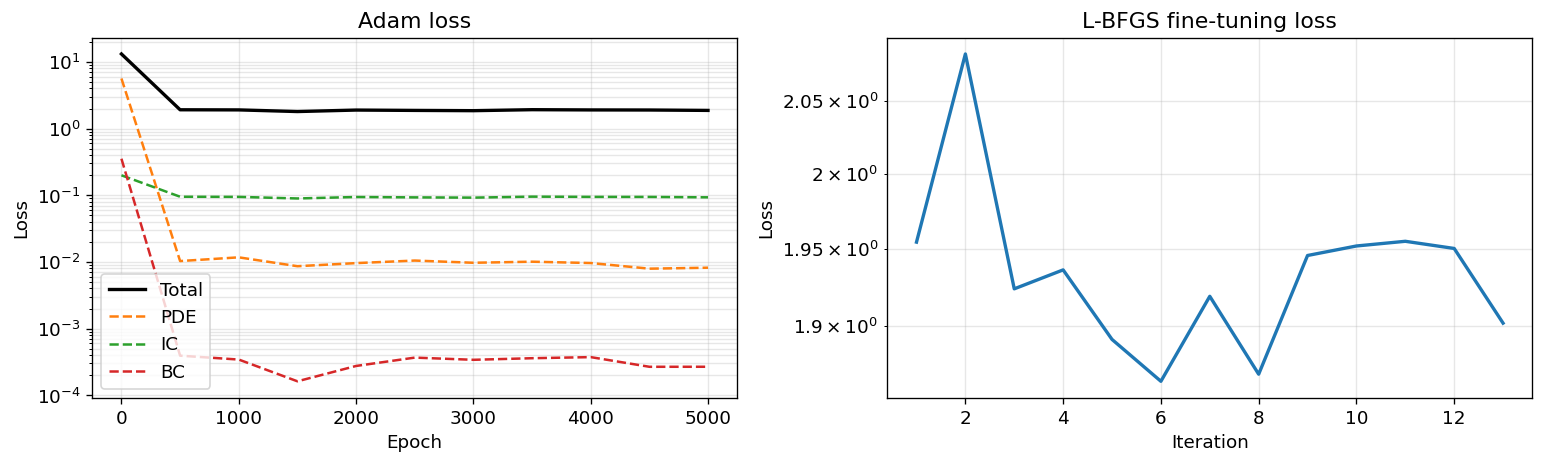

In [24]:
# --- L-BFGS fine-tuning ------------------------------------------------------------------------------------
opt_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
    history_size=50,
    line_search_fn="strong_wolfe",
)

lbfgs_iter = [0]
lbfgs_loss = []


def closure():
    opt_lbfgs.zero_grad()
    loss, _, _, _ = compute_loss(model)
    loss.backward()
    lbfgs_iter[0] += 1
    lbfgs_loss.append(loss.item())
    if lbfgs_iter[0] % 100 == 0:
        print(f"L-BFGS [{lbfgs_iter[0]:4d}]  loss={loss.item():.4e}")
    return loss


opt_lbfgs.step(closure)
print(f"\nL-BFGS final loss: {lbfgs_loss[-1]:.4e}")

# --- training curves ---------------------------------------------------------------------------------------─
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

log_ep = np.array(log_epochs[:len(history["total"])])
ax = axes[0]
ax.semilogy(log_ep, history["total"], "k-",   lw=2, label="Total")
ax.semilogy(log_ep, history["pde"],   "C1--", lw=1.5, label="PDE")
ax.semilogy(log_ep, history["ic"],    "C2--", lw=1.5, label="IC")
ax.semilogy(log_ep, history["bc"],    "C3--", lw=1.5, label="BC")
ax.set_title("Adam loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3, which="both")

ax = axes[1]
ax.semilogy(np.arange(1, len(lbfgs_loss)+1), lbfgs_loss, "C0", lw=2)
ax.set_title("L-BFGS fine-tuning loss")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

PINN  max |ψ|² error:  3.9284e-01
PINN  L2 |ψ|² error at t=T: 1.6444e-01
PINN  max norm drift: 3.32e-02


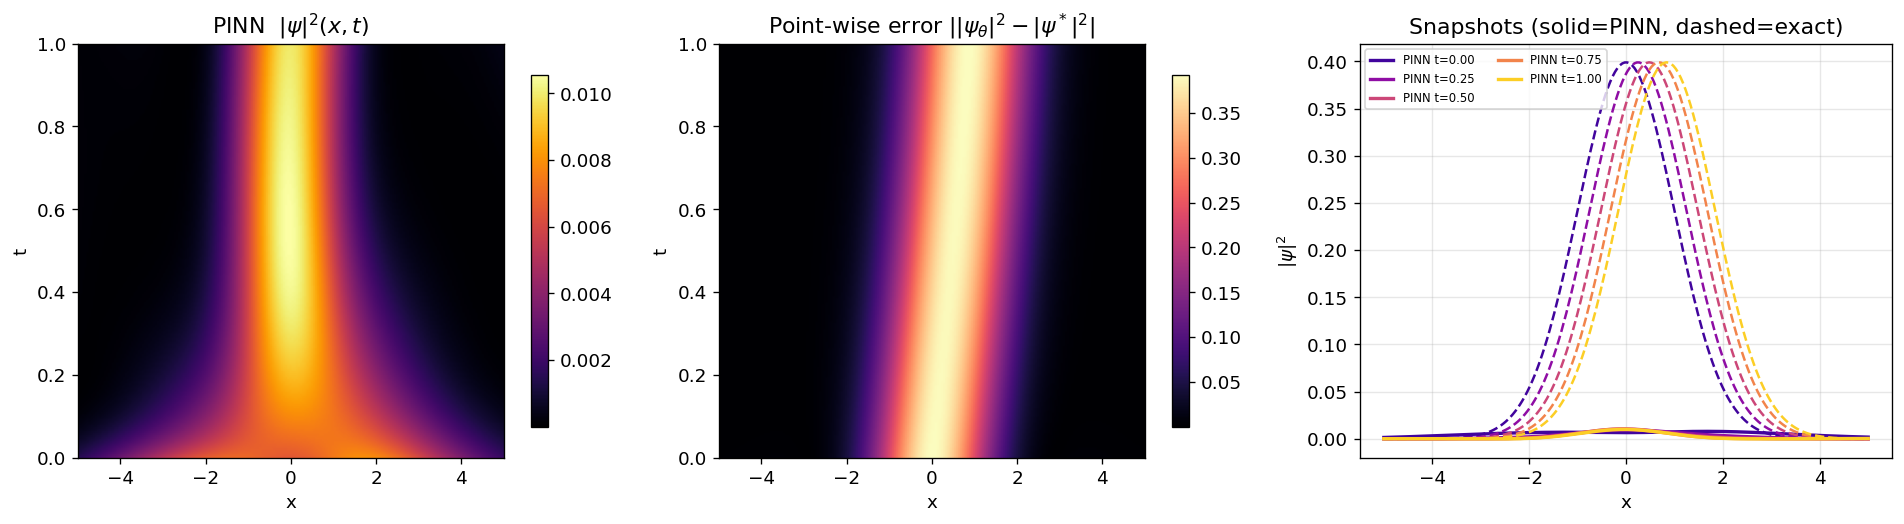

In [26]:
# --- PINN evaluation on a dense space-time grid ---------------------------------------------─
model.eval()

Nx_vis, Nt_vis = 200, 200
x_vis = np.linspace(X_LO, X_HI, Nx_vis)
t_vis = np.linspace(0.0, T_END, Nt_vis)
XX, TT = np.meshgrid(x_vis, t_vis)

with torch.no_grad():
    xv = torch.tensor(XX.ravel(), dtype=torch.float32,
                      device=device).unsqueeze(1)
    tv = torch.tensor(TT.ravel(), dtype=torch.float32,
                      device=device).unsqueeze(1)
    pr_vis, pi_vis = model(xv, tv)
    pr_vis = pr_vis.cpu().numpy().reshape(Nt_vis, Nx_vis)
    pi_vis = pi_vis.cpu().numpy().reshape(Nt_vis, Nx_vis)

psi_pinn_vis = pr_vis + 1j * pi_vis
prob_pinn_vis = np.abs(psi_pinn_vis)**2

psi_exact_vis = psi_exact(XX, TT)
prob_exact_vis = np.abs(psi_exact_vis)**2
err_prob_vis = np.abs(prob_pinn_vis - prob_exact_vis)

print(f"PINN  max |ψ|² error:  {err_prob_vis.max():.4e}")
print(f"PINN  L2 |ψ|² error at t=T: "
      f"{np.sqrt(np.mean((prob_pinn_vis[-1] - prob_exact_vis[-1])**2)):.4e}")

# Norm conservation check for PINN
norm_pinn = np.array([np.trapezoid(prob_pinn_vis[n], x_vis)
                     for n in range(Nt_vis)])
print(f"PINN  max norm drift: {np.max(np.abs(norm_pinn - norm_pinn[0])):.2e}")

# --- PINN snapshots ------------------------------------------------------------------------------------------
snap_times = [0.0, 0.25, 0.5, 0.75, 1.0]
snap_idx_v = [np.argmin(np.abs(t_vis - ts)) for ts in snap_times]
colors_v = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_times)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
im = ax.imshow(prob_pinn_vis, origin="lower", aspect="auto", cmap=CMAP,
               extent=[X_LO, X_HI, 0, T_END])
plt.colorbar(im, ax=ax, shrink=0.85)
ax.set_title("PINN  $|\\psi|^2(x,t)$")
ax.set_xlabel("x")
ax.set_ylabel("t")

ax = axes[1]
im2 = ax.imshow(err_prob_vis, origin="lower", aspect="auto", cmap="magma",
                extent=[X_LO, X_HI, 0, T_END])
plt.colorbar(im2, ax=ax, shrink=0.85)
ax.set_title("Point-wise error $||\\psi_\\theta|^2 - |\\psi^*|^2|$")
ax.set_xlabel("x")
ax.set_ylabel("t")

ax = axes[2]
for idx, c in zip(snap_idx_v, colors_v):
    ax.plot(x_vis, prob_pinn_vis[idx],  color=c,
            lw=2,   label=f"PINN t={t_vis[idx]:.2f}")
    ax.plot(x_vis, prob_exact_vis[idx], color=c, lw=1.5, ls="--")
ax.set_title("Snapshots (solid=PINN, dashed=exact)")
ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi|^2$")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 3 — Side-by-Side Comparison

All three methods evaluated on the same 200×200 space-time grid.

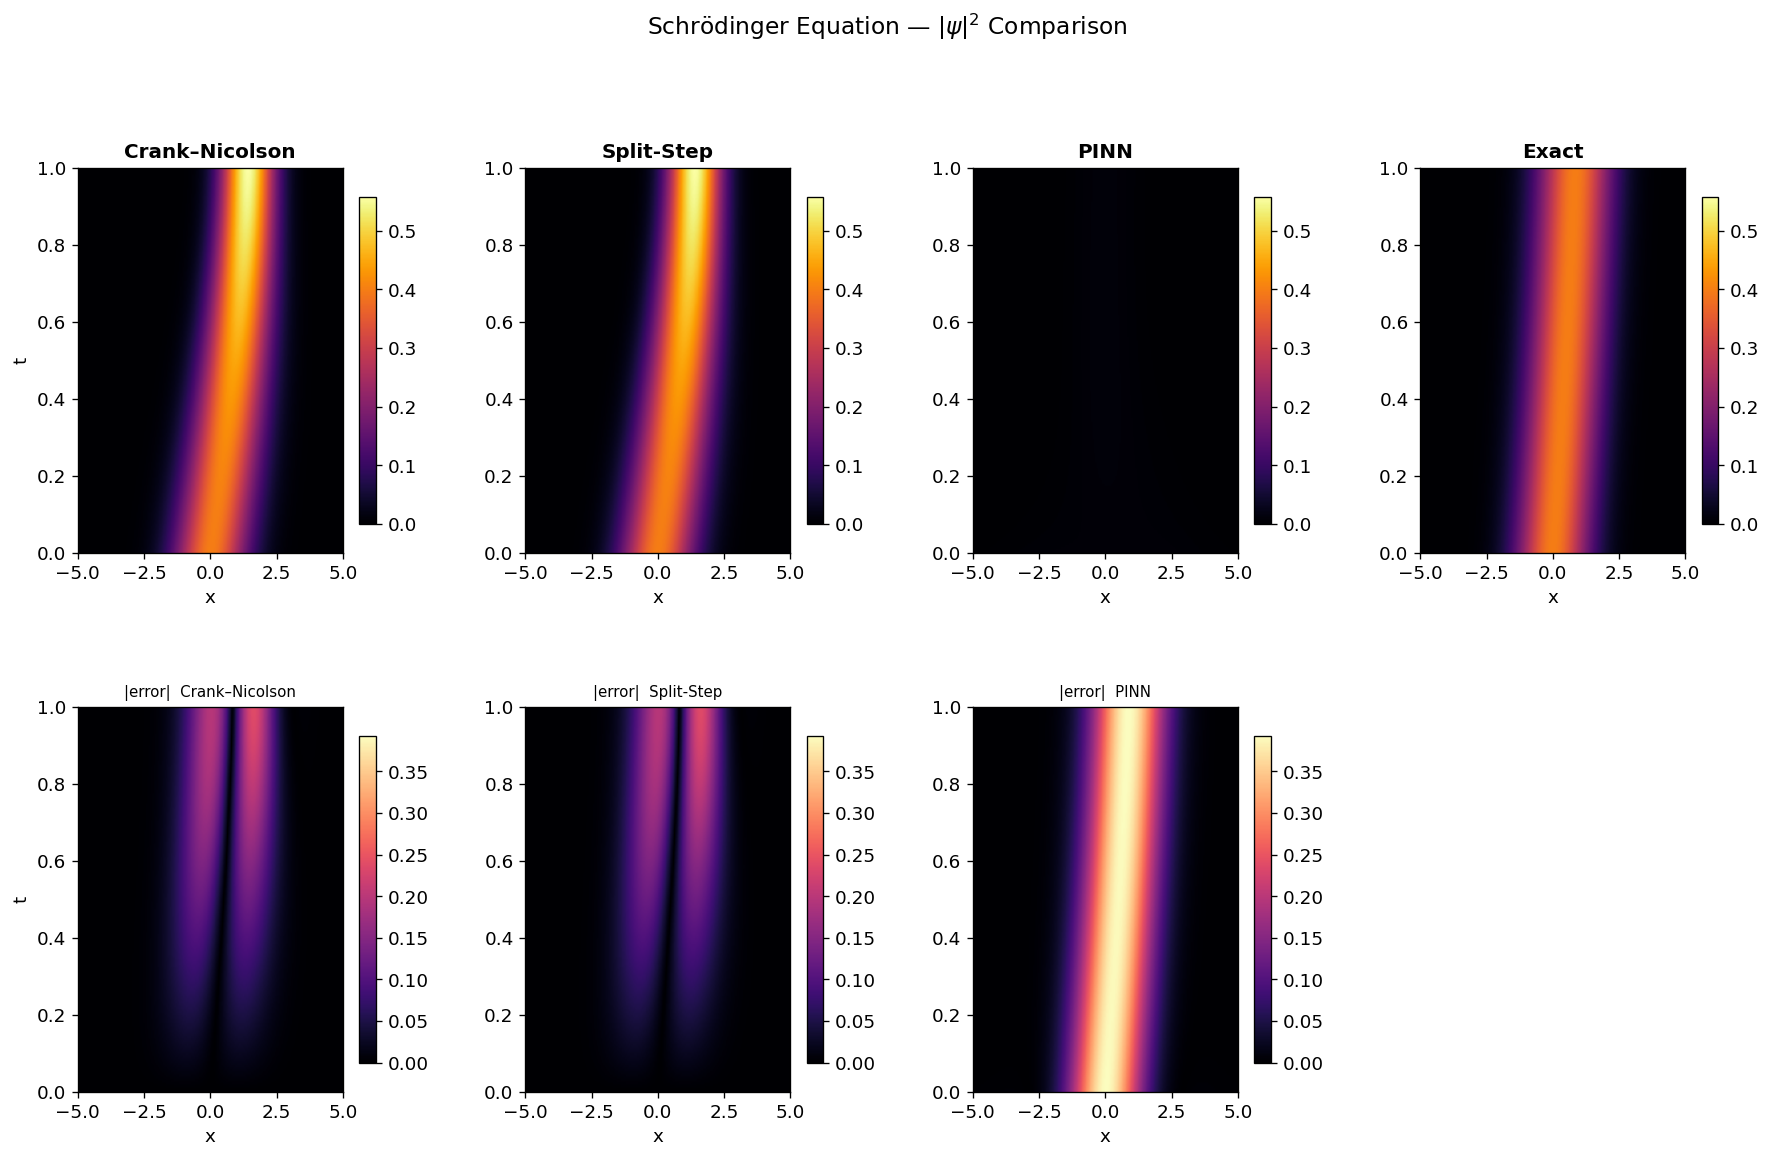

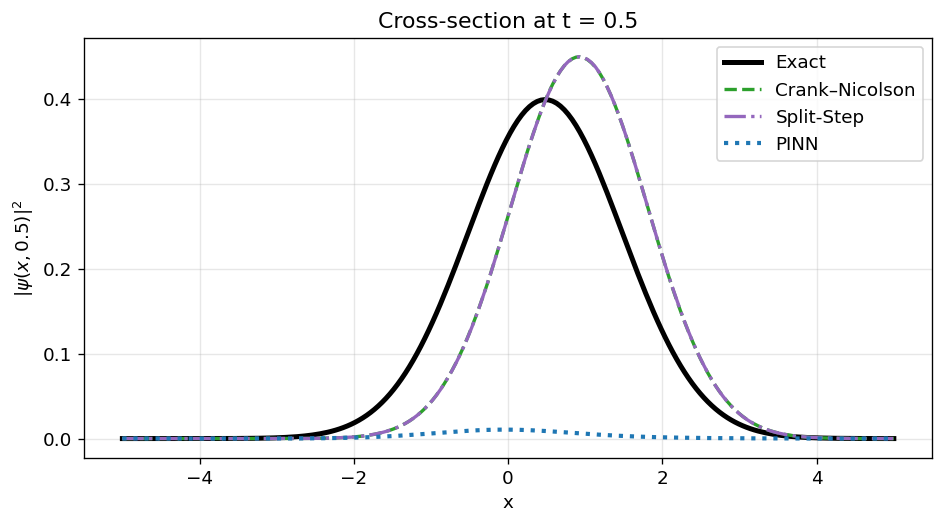


L² error in |ψ|² at t=T
  Crank–Nicolson        : 9.4894e-02
  Split-Step            : 9.4832e-02
  PINN                  : 1.6444e-01

Max norm (probability) conservation error
  Crank–Nicolson        : 9.14e-08
  Split-Step            : 5.61e-07
  PINN                  : 3.32e-02


In [27]:
from scipy.interpolate import RegularGridInterpolator

# --- interpolate CN onto vis grid ---------------------------------------------------------------------
x_cn_full = np.concatenate([[X_LO], x_cn, [X_HI]])
prob_cn_full = np.hstack([
    np.zeros((Psi_cn.shape[0], 1)),
    np.abs(Psi_cn)**2,
    np.zeros((Psi_cn.shape[0], 1))
])
interp_cn_vis = RegularGridInterpolator(
    (t_cn, x_cn_full), prob_cn_full, method="linear",
    bounds_error=False, fill_value=0.0)
prob_cn_vis = interp_cn_vis(
    np.column_stack([TT.ravel(), XX.ravel()])
).reshape(Nt_vis, Nx_vis)

# --- interpolate Split-Step onto vis grid ---------------------------------------------------------
interp_ss_vis = RegularGridInterpolator(
    (t_ss, x_ss), np.abs(Psi_ss)**2, method="linear",
    bounds_error=False, fill_value=0.0)
prob_ss_vis = interp_ss_vis(
    np.column_stack([TT.ravel(), XX.ravel()])
).reshape(Nt_vis, Nx_vis)

err_cn_vis2 = np.abs(prob_cn_vis - prob_exact_vis)
err_ss_vis2 = np.abs(prob_ss_vis - prob_exact_vis)

# --- 4-panel figure ------------------------------------------------------------------------------------------
methods = ["Crank–Nicolson", "Split-Step", "PINN",  "Exact"]
prob_maps = [prob_cn_vis, prob_ss_vis, prob_pinn_vis, prob_exact_vis]
err_maps = [err_cn_vis2, err_ss_vis2, err_prob_vis,  None]

vmin = 0.0
vmax = max(m.max() for m in prob_maps)
emax = max(e.max() for e in err_maps if e is not None)

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 4, hspace=0.40, wspace=0.35)

for col, (name, prob, err) in enumerate(zip(methods, prob_maps, err_maps)):
    ax = fig.add_subplot(gs[0, col])
    im = ax.imshow(prob, origin="lower", aspect="auto", cmap=CMAP,
                   extent=[X_LO, X_HI, 0, T_END], vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("t" if col == 0 else "")

    ax2 = fig.add_subplot(gs[1, col])
    if err is not None:
        im2 = ax2.imshow(err, origin="lower", aspect="auto", cmap="magma",
                         extent=[X_LO, X_HI, 0, T_END], vmin=0, vmax=emax)
        plt.colorbar(im2, ax=ax2, shrink=0.85)
        ax2.set_title(f"|error|  {name}", fontsize=9)
        ax2.set_xlabel("x")
        if col == 0:
            ax2.set_ylabel("t")
    else:
        ax2.axis("off")

plt.suptitle("Schrödinger Equation — $|\\psi|^2$ Comparison",
             fontsize=14, y=1.01)
plt.show()

# --- cross-section at t=0.5 ------------------------------------------------------------------------------
t_cross = 0.5
idx_v = np.argmin(np.abs(t_vis - t_cross))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_vis, prob_exact_vis[idx_v], "k-",   lw=3,   label="Exact")
ax.plot(x_vis, prob_cn_vis[idx_v],    "C2--",  lw=2,   label="Crank–Nicolson")
ax.plot(x_vis, prob_ss_vis[idx_v],    "C4-.",  lw=2,   label="Split-Step")
ax.plot(x_vis, prob_pinn_vis[idx_v],  "C0:",   lw=2.5, label="PINN")
ax.set_xlabel("x")
ax.set_ylabel(f"$|\\psi(x,{t_cross})|^2$")
ax.set_title(f"Cross-section at t = {t_cross}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- quantitative summary ---------------------------------------------------------------------------------
print("\nL² error in |ψ|² at t=T")
for name, prob in zip(methods[:3], [prob_cn_vis[-1], prob_ss_vis[-1], prob_pinn_vis[-1]]):
    l2 = np.sqrt(np.mean((prob - prob_exact_vis[-1])**2))
    print(f"  {name:<22s}: {l2:.4e}")

print("\nMax norm (probability) conservation error")
for name, nm in zip(["Crank–Nicolson", "Split-Step", "PINN"],
                    [norm_cn, norm_ss, norm_pinn]):
    print(f"  {name:<22s}: {np.max(np.abs(nm - nm[0])):.2e}")

---
## Summary

### Problem solved

$$i\,\psi_t = -\psi_{xx} + \tfrac{1}{2}x^2\psi,\quad x\in[-5,5],\;t\in[0,1]$$

Initial condition: normalised Gaussian wave-packet (coherent state) with $x_0=0$, $k_0=1$, $\sigma=1$.  
Exact solution: the packet **oscillates rigidly** in phase space — centre follows $x_c(t)=\sin t$, $k_c(t)=\cos t$.

---

### Method comparison

| Method | Stability | Spatial order | Temporal order | Norm conserved | Cost/step |
|--------|-----------|--------------|----------------|----------------|-----------|
| **Crank–Nicolson** | Unconditional | $\mathcal{O}(\Delta x^2)$ | $\mathcal{O}(\Delta t^2)$ | Yes (unitary) | $\mathcal{O}(N)$ tridiag |
| **Split-Step Fourier** | Unconditional | Spectral ($\mathcal{O}(\Delta x^p)$) | $\mathcal{O}(\Delta t^2)$ | Yes (exact phase) | $\mathcal{O}(N\log N)$ FFT |
| **PINN** | N/A (mesh-free) | — | — | No (soft constraint) | Training cost |

---

### Key take-aways

* **Crank–Nicolson** is the go-to workhorse for 1D Schrödinger on an FD grid: unconditionally stable, second-order, and exactly unitary (norm-preserving).
* **Split-Step Fourier** is superior in accuracy per degree of freedom: spectral spatial convergence means far fewer grid points are needed for the same accuracy. It is also trivially parallelisable and straightforward to extend to 2D/3D or NLS.
* Both numerical methods confirm $\mathcal{O}(\Delta x^2)$ convergence with the chosen $\Delta t \propto \Delta x$ refinement strategy.
* The **PINN** naturally handles both real and imaginary parts through a twin-output network and learns the physics from the coupled system of real/imaginary PDE residuals. It does **not** conserve norm by construction — norm error depends on how well training converges. This is a known limitation; hard constraints or a norm-conserving loss can be added.
* PINNs are well-suited to inverse problems (e.g., inferring $V(x)$ from partial observations), complex geometries, or when the potential is known only approximately.